# scProto niche recovery on `bk08` -- ema vs. nk vs. SEACells (`crcx`)

Mirrors `ctx_pca_product_experiment.ipynb`'s current structure exactly (same `bk08`/`arbf` graphs, same `ema`/`nk` fast-path comparison, same full `report_run`/`report_all` DGE eval harness), retargeted to `crcx` (CRC Xenium, second spatial dataset for the rebuttal -- different tissue and platform than `s28nsc`).

Tests whether scProto (`bk08` affinity: real `pybanksy` package, lambda=0.8, kernel built with the real SEACells package's own `SEACellGraph.rbf()`) can recover niche-transcriptional-program DGE signal (Branch 1/2), comparing:

- **`proto_usage_mode`**: `ema` (max-based, satisfied by one confident cell per prototype) vs. `nk` (sum-based aggregate mass, EMA-smoothed across batches).
- **Method**: scProto vs. SEACells archetypal analysis, on both the standard `arbf`-on-PCA graph (the unmodified SEACells(PCA) baseline) and the same `bk08` graph scProto trains on (isolates method from graph choice).

**To change the affinity types, prototype count, or epoch count**: load the dataset first (below), read off the printed (celltype, niche) pair count, then edit the single config cell right after it (`BNK_AFFINITY` / `BASELINE_AFFINITY` / `N_PROTOTYPES` / `TRAIN_EPOCHS`) before running anything else.

Run this in Colab -- needs the Drive-mounted `data/` and `models/` folders.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Same base install as ctx_pca_product_experiment.ipynb / plan1_niche_recovery_eval.ipynb --
# no anndata version pin (no single anndata version satisfies both scarches/scvi-tools
# and SEACells -- the actual SEACells `dtype=` TypeError is patched at its call site
# in metacell_metrics.py instead). pybanksy added explicitly (bk08 needs it) -- the
# reference notebook's own install cell omits it, presumably relying on an already-
# warm Colab environment from an earlier pybanksy install in the same session.
# fsspec/h5py added for the self-heal cell below (only actually used if the prepped
# file is missing layers['counts']).
!pip install -q scarches faiss-cpu scib-metrics
!pip install git+https://github.com/dpeerlab/SEACells.git --quiet --no-deps
!pip install numpy scipy --upgrade -q
!pip install -q palantir harmonypy statsmodels leidenalg python-igraph fsspec aiohttp h5py
!pip install -q "numpy==1.26.4" "scipy==1.13.1"
!pip install --upgrade --force-reinstall numpy cupy-cuda12x
!pip install "numpy<2.3"
!pip install -q pybanksy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 177.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 208.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 206.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 220.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 230.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 164.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 711.2/711.2 kB 81.2 MB/s eta 0:00:00
   ━

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 232.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.1
    Uninstalling numpy-2.5.1:
      Successfully uninstalled numpy-2.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
seacells 0.3.3 requires pyranges, which is not installed.
anndata 0.13.2 requires scipy!=1.17.0,>=1.14, but you have scipy 1.13.1 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.66.0 which is incompatible.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.66.0 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.66.0 whi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.3/83.3 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
seacells 0.3.3 requires pyranges, which is not installed.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.66.0 which is incompatible.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.66.0 which is incompatible.


**IMPORTANT: restart the runtime now** (Runtime -> Restart session) before running the cells below.

In [1]:
_checks = {
    "numpy": "numpy", "scipy": "scipy", "anndata": "anndata", "scanpy": "scanpy",
    "scarches": "scarches", "scvi-tools": "scvi", "seacells": "SEACells",
    "palantir": "palantir", "scib-metrics": "scib_metrics",
    "statsmodels": "statsmodels", "faiss": "faiss", "leidenalg": "leidenalg",
    "banksy": "banksy", "fsspec": "fsspec", "h5py": "h5py",
}
_failed = []
for pkg, mod in _checks.items():
    try:
        __import__(mod)
    except ImportError as e:
        _failed.append((pkg, str(e)))
if _failed:
    print("FAILED imports (fix before continuing, then restart runtime again):")
    for pkg, err in _failed:
        print(f"  {pkg}: {err}")
else:
    print("All packages import cleanly.")

FAILED imports (fix before continuing, then restart runtime again):
  scarches: cannot import name 'read' from 'anndata' (/usr/local/lib/python3.12/dist-packages/anndata/__init__.py)


In [2]:
%run /content/drive/MyDrive/codes/interpretable-prototype/notebooks/nb_setup.py


nb_setup done. Available: get_trainer, run_mc_task, fig_*, LAMBDA_PROTO_UMAP, LAMBDA_PROTO_UMAP_PRECON, LAMBDA_PARAM_UMAP, LAMBDA_RECON_ONLY, train_sure, eval_sure_task1/2/3
Configs: {'LAMBDA_PROTO_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'proto'}, 'LAMBDA_PARAM_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'embedding'}, 'LAMBDA_RECON_ONLY': {'lambda_umap': 0, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 1, 'lambda_proto_recon': 0.0}}


In [3]:
import os
import pickle

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import scipy.sparse as sp

from interpretable_ssl.datasets.dataset_configs import DATASETS
from interpretable_ssl.configs.paths import CODE_DIR, get_affinity_path
from interpretable_ssl.augmenters.graph_generator import generate_affinity, _ensure_X_ctx
from interpretable_ssl.evaluation.batch_correct_baselines import run_seacells_on_latent
from interpretable_ssl.evaluation.niche_program_recovery import (
    compute_ground_truth, save_ground_truth, load_ground_truth,
    majority_label_metacells, load_cell_assignments,
    build_pseudobulk, branch1_recovery, branch2_recovery, macro_average,
    per_pair_diagnostics,
    load_soft_assignments, soft_label_metacells, build_soft_pseudobulk,
    size_concentration_summary,
)

DS_ID = 'crcx'          # CRC Xenium, 3 whole sections (g_core/l_normal/d_normal),
                          # ~50,130 cells -- spatial neighborhoods intact.
CT_KEY = 'celltype'
NICHE_KEY = 'Niche'      # NicheCompass-derived ground-truth label from the source
                          # paper -- used here only to define ground-truth DE pairs,
                          # NOT the composition-clustering niche our own method uses.
BATCH_KEY = DATASETS[DS_ID].get('batch_key')
K_GRAPH = 50              # matches configs/defaults.py's k_neighbors default

GT_PATH = os.path.join(CODE_DIR, 'files', 'celltype_niches_full_crcx.csv')

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 150


## Load dataset, check (celltype, niche) pair count, then configure the run

In [4]:
ds_conf = DATASETS[DS_ID]
adata = sc.read_h5ad(ds_conf['path'])
print(adata)
print('\ncell types:\n', adata.obs[CT_KEY].value_counts())
print('\nniches:\n', adata.obs[NICHE_KEY].value_counts(dropna=False))
print('\npatients (batch):\n', adata.obs[BATCH_KEY].value_counts())
print('\nX max (sanity check, should be well under 30 -- already log-normalized):', adata.X.max())
print('layers[counts] present:', 'counts' in adata.layers)

# --- (cell type, niche) pair counts -- look at this BEFORE setting N_PROTOTYPES
# in the config cell below. This raw crosstab is every combination present in
# the data; compute_ground_truth further down will filter it down to pairs
# passing the min_pos=5/min_ctrl=20 thresholds (a smaller, real number -- this
# is just the ceiling). As a rule of thumb you want N_PROTOTYPES comfortably
# larger than this count, so DGE scoring isn't starved for metacells per pair.
ct_niche_counts = adata.obs.groupby([CT_KEY, NICHE_KEY], observed=True).size()
ct_niche_counts = ct_niche_counts[ct_niche_counts > 0].sort_values(ascending=False)
print(f'\n=== {len(ct_niche_counts)} distinct (celltype, niche) combinations present in the raw data ===')
print(ct_niche_counts)


AnnData object with n_obs × n_vars = 50130 × 380
    obs: 'patient_id', 'region', 'slide', 'tissue_region', 'celltype', 'Niche', 'CN'
    uns: 'pca'
    obsm: 'X_pca', 'spatial'
    varm: 'PCs'
    layers: 'counts', None (.X)

cell types:
 celltype
Epithelial cell       19691
Cancer cell            8327
Fibroblast             7874
Plasma cell            4589
Macrophage             2271
Endothelial cell       2196
T cell                 1974
Smooth muscle cell     1903
Neutrophil              370
Mast cell               345
Schwann cell            280
Dendritic cell          223
B cell                   87
Name: count, dtype: int64

niches:
 Niche
Epithelial niche                37839
Stromal niche                    7381
Cancer                           3430
Cancer - myeloid-enriched         817
Cancer - fibroblast-enriched      663
Name: count, dtype: int64

patients (batch):
 patient_id
d    32788
l    10330
g     7012
Name: count, dtype: int64

X max (sanity check, should be well un

In [5]:
# Self-heal: if the prepped file is missing layers['counts'] (e.g. it was built
# before that fix was added to crc_xenium_data_prep.ipynb), fetch it directly
# from the source CRC h5ad right here and patch + resave -- so this notebook
# doesn't depend on a separate notebook having been re-run correctly.
#
# Relies on adata.obs_names being the ORIGINAL row position (as a string) in
# the 3.7M-cell source file -- true here because crc_xenium_data_prep.ipynb's
# whole-sections Step 3 subsets via boolean masking (`full[keep_mask]`), which
# preserves the original obs index rather than renumbering it.
if 'counts' in adata.layers:
    print("adata.layers['counts'] already present -- nothing to do.")
else:
    print("adata.layers['counts'] missing -- fetching from source and patching in place ...")
    import fsspec, h5py, scipy.sparse as sp2, time as _time

    CRC_URL = 'https://ftp.ebi.ac.uk/biostudies/fire/S-BIAD/208/S-BIAD2208/Files/xenium/processed/crca_xenium.h5ad'
    _of = fsspec.open(CRC_URL, mode='rb', block_size=4 * 1024 * 1024)
    h5_src = h5py.File(_of.open(), 'r')

    row_idx = adata.obs_names.astype(int).to_numpy()
    order = np.argsort(row_idx)
    sorted_idx = row_idx[order]

    grp = h5_src['layers']['counts']
    full_shape = tuple(int(v) for v in grp.attrs['shape'])
    print(f'Reading full layers/counts (shape={full_shape}) from source, '
          f'then selecting our {len(row_idx)} cells ...')
    t0 = _time.time()
    indptr = grp['indptr'][:]
    data = grp['data'][:]
    indices = grp['indices'][:]
    print(f'  read in {_time.time() - t0:.1f}s')
    counts_full = sp2.csr_matrix((data, indices, indptr), shape=full_shape)
    del data, indices, indptr

    counts_sub_sorted = counts_full[sorted_idx]
    inverse = np.argsort(order)
    counts_sub = counts_sub_sorted[inverse]  # restore adata's own row order
    del counts_full, counts_sub_sorted

    assert counts_sub.shape[0] == adata.n_obs, \
        f'row count mismatch: got {counts_sub.shape[0]}, expected {adata.n_obs}'
    adata.layers['counts'] = counts_sub
    print('counts sample values (should be integers, raw):', adata.layers['counts'].data[:10])

    print(f'Patched. Saving back to {ds_conf["path"]} so this fix is permanent ...')
    adata.write_h5ad(ds_conf['path'])
    print('Saved -- future loads of this file will already have layers[counts].')

adata.layers['counts'] already present -- nothing to do.


In [6]:
# arbf's kernel (SEACells.build_graph.SEACellGraph(ad, "X_pca", ...)) reads
# adata.obsm['X_pca'] directly with no fallback -- compute it once here if
# missing, and save back to disk so future fresh reloads (e.g. inside
# run_mc_task, which reloads a FRESH copy of this file for every training
# call) don't need to recompute it either. We do NOT need X_ctx itself for
# bk08/arbf, so this is a plain PCA, not the full _ensure_X_ctx pipeline.
if 'X_pca' in adata.obsm:
    print("adata.obsm['X_pca'] already present -- nothing to do.")
else:
    print("adata.obsm['X_pca'] missing -- computing (sc.tl.pca) and saving back ...")
    sc.tl.pca(adata)
    adata.write_h5ad(ds_conf['path'])
    print(f"Saved. X_pca shape: {adata.obsm['X_pca'].shape}")

adata.obsm['X_pca'] already present -- nothing to do.


In [7]:
# ============================== EDIT HERE ==============================
# Set N_PROTOTYPES after looking at the (celltype, niche) pair count printed
# just above -- want it comfortably larger than that count (ctx_pca_product_
# experiment.ipynb's s28nsc run used N_PROTOTYPES=200, picked to be close to
# its own real pair count via a separate Leiden-community-count analysis; do
# the same reasoning here with the number printed above instead of copying 200).
BNK_AFFINITY = 'bk08'        # real pybanksy package, lambda=0.8 (domain-segmentation
                               # default), num_neighbours=32, kernel built with the
                               # REAL SEACells package's own SEACellGraph.rbf()
                               # (not our rbf_optimized reimplementation) -- see
                               # graph_generator.py's 'bk08' branch.
BASELINE_AFFINITY = 'arbf'   # standard, unmodified SEACells recipe: adaptive-
                               # bandwidth RBF on plain PCA, no graph engineering --
                               # the true SEACells(PCA) baseline.
N_PROTOTYPES = 200           # override with an int -- see note above.
TRAIN_EPOCHS = 20            # scProto train_epochs for BOTH ema and nk runs
                               # (same epoch count for a fair, apples-to-apples
                               # comparison -- no epoch-count confound).
# =========================================================================

print(f'BNK_AFFINITY = {BNK_AFFINITY!r}')
print(f'BASELINE_AFFINITY = {BASELINE_AFFINITY!r}')
print(f'N_PROTOTYPES = {N_PROTOTYPES}  ({N_PROTOTYPES / len(ct_niche_counts):.1f}x the {len(ct_niche_counts)} observed (celltype, niche) pairs)')
print(f'TRAIN_EPOCHS = {TRAIN_EPOCHS}')


BNK_AFFINITY = 'bk08'
BASELINE_AFFINITY = 'arbf'
N_PROTOTYPES = 200  (3.7x the 54 observed (celltype, niche) pairs)
TRAIN_EPOCHS = 20


## Load ground truth (DGE per (celltype, niche) pair)

In [8]:
if os.path.exists(GT_PATH):
    print(f'Loading cached ground truth from {GT_PATH}')
    ground_truth = load_ground_truth(GT_PATH)
else:
    ground_truth = compute_ground_truth(adata, CT_KEY, NICHE_KEY, min_pos=5, min_ctrl=20)
    save_ground_truth(ground_truth, GT_PATH)
    n_rows = sum(len(v) for v in ground_truth.values())
    print(f'Saved full ground truth ({n_rows} gene rows across {len(ground_truth)} '
          f'(cell type, niche) pairs) to {GT_PATH}')

print(f'{len(ground_truth)} (cell type, niche) pairs pass the 5/20-cell minimum')

n_target = len(ground_truth)
print(f'Target: {n_target} real (cell type, niche) pairs in ground truth')


Loading cached ground truth from /content/drive/MyDrive/codes/interpretable-prototype/files/celltype_niches_full_crcx.csv
46 (cell type, niche) pairs pass the 5/20-cell minimum
Target: 46 real (cell type, niche) pairs in ground truth


In [9]:
# One shared report for any already-trained run: loads cell_assignments.csv
# (hard) and soft_assignments.npz (soft, if present) and scores both the same
# way -- Branch 1/2 summary, size-concentration (gini/effective_n/top5-share),
# and a per-(cell type, niche) breakdown. Reused by every section below and for
# re-inspecting a checkpoint that already finished training (no re-encoding, no
# retraining -- just reads the two saved files).
def report_run(name, run_dir, adata, ground_truth, ct_key=CT_KEY, niche_key=NICHE_KEY):
    summary_rows = {}
    size_rows = []
    per_pair_rows = []

    # ---- hard ----
    cell_assign = load_cell_assignments(run_dir, adata, niche_key)
    mc_labels = majority_label_metacells(cell_assign, ct_key, niche_key)
    pseudobulk = build_pseudobulk(cell_assign, adata)
    b1 = branch1_recovery(pseudobulk, mc_labels, ground_truth)
    b2 = branch2_recovery(pseudobulk, mc_labels, ground_truth)
    row = macro_average(b1, ['pearson_r', 'kendall_tau'])
    row['tpr'] = macro_average(b2, ['tpr'])['tpr']
    row['n_pairs_tested'] = len(b1)
    summary_rows[f'{name} (hard)'] = row
    size_rows.append(size_concentration_summary(mc_labels['n_cells'], name=f'{name} (hard)'))
    pp = per_pair_diagnostics(mc_labels, b1, b2)
    pp['run'] = f'{name} (hard)'
    per_pair_rows.append(pp)

    # ---- soft (skipped if this run predates soft_assignments.npz saving) ----
    npz_path = os.path.join(run_dir, 'soft_assignments.npz')
    if os.path.exists(npz_path):
        S, cell_ids = load_soft_assignments(run_dir)
        mc_labels_soft = soft_label_metacells(S, cell_ids, adata, ct_key, niche_key)
        pseudobulk_soft = build_soft_pseudobulk(S, cell_ids, adata)
        b1s = branch1_recovery(pseudobulk_soft, mc_labels_soft, ground_truth)
        b2s = branch2_recovery(pseudobulk_soft, mc_labels_soft, ground_truth)
        row_s = macro_average(b1s, ['pearson_r', 'kendall_tau'])
        row_s['tpr'] = macro_average(b2s, ['tpr'])['tpr']
        row_s['n_pairs_tested'] = len(b1s)
        summary_rows[f'{name} (soft)'] = row_s
        size_rows.append(size_concentration_summary(mc_labels_soft['n_cells'], name=f'{name} (soft)'))
        pps = per_pair_diagnostics(mc_labels_soft, b1s, b2s)
        pps['run'] = f'{name} (soft)'
        per_pair_rows.append(pps)
    else:
        print(f'{name}: no soft_assignments.npz found, soft scoring skipped')

    summary_df = pd.DataFrame(summary_rows).T
    size_df = pd.DataFrame(size_rows).set_index('run')
    per_pair_df = pd.concat(per_pair_rows, ignore_index=True)
    return summary_df, size_df, per_pair_df


def report_all(run_dirs, missing, adata, ground_truth, ct_key=CT_KEY, niche_key=NICHE_KEY):
    """report_run for every run in run_dirs not in missing, concatenated into
    one summary / size / per-pair table each."""
    summaries, sizes, pairs = [], [], []
    for name, run_dir in run_dirs.items():
        if name in missing:
            continue
        s, z, p = report_run(name, run_dir, adata, ground_truth, ct_key, niche_key)
        summaries.append(s)
        sizes.append(z)
        pairs.append(p)
        print(f'{name}: done')
    return pd.concat(summaries), pd.concat(sizes), pd.concat(pairs, ignore_index=True)


PER_PAIR_COLS = ['run', 'cell_type', 'niche', 'n_pos_mc', 'median_pos_mc_size',
                  'min_pos_mc_size', 'mean_niche_purity', 'pearson_r', 'kendall_tau', 'tpr']


## Fast path: `bk08`, `ema` vs. `nk`, both at `TRAIN_EPOCHS`

Same graph (`bk08`) and `N_PROTOTYPES` throughout -- only `proto_usage_mode` varies, both run the same `TRAIN_EPOCHS` for a fair, apples-to-apples comparison (no epoch-count confound).

- **`ema`** (previous active default) -- max-based: satisfied by one confident cell per prototype, blind to total population.
- **`nk`** (now the default in `scproto.py`) -- sum-based aggregate mass, EMA-smoothed across batches so a genuinely rare population isn't penalized just for sampling unluckily into a low-count batch. Fixes `ema`'s blindness to total headcount.

Imports + training loop:

In [10]:
from interpretable_ssl.experiments.tasks import run_mc_task, LAMBDA_PROTO_UMAP_PRECON
from interpretable_ssl.evaluation.batch_correct_baselines import _topk_sparsify_rows, save_soft_assignments
import torch
import torch.nn.functional as F

trainers_usage_mode = {}


In [11]:
lc = dict(LAMBDA_PROTO_UMAP_PRECON)

exp_name = f'proto_{BNK_AFFINITY}_np{N_PROTOTYPES}_ema{TRAIN_EPOCHS}'
try:
    print(f'Trying to load an existing ema/{TRAIN_EPOCHS}ep checkpoint (no retraining)...')
    t, _, _ = run_mc_task(
        DS_ID, cvae_epochs=50, train_epochs=1, eval_freq=1, patience=1,
        batch_size=1024, affinity_type=BNK_AFFINITY, lambda_config=lc,
        num_prototypes=N_PROTOTYPES,
        trainer_kwargs={'experiment_name': exp_name},
        load_umap=True, skip_eval=True,
    )
    print('Loaded.')
except FileNotFoundError:
    print(f'=== training scProto: {BNK_AFFINITY}, N_PROTOTYPES={N_PROTOTYPES}, '
          f'proto_usage_mode=ema, {TRAIN_EPOCHS} epochs ===')
    t, metrics, _ = run_mc_task(
        DS_ID, cvae_epochs=50, train_epochs=TRAIN_EPOCHS, eval_freq=5, patience=10,
        batch_size=1024, lambda_config=lc, affinity_type=BNK_AFFINITY,
        trainer_kwargs={'experiment_name': exp_name},
        label_key=CT_KEY, niche_key=NICHE_KEY, num_prototypes=N_PROTOTYPES,
        skip_metrics=['task2', 'task3'],
    )
print(f'  epsilon={t.epsilon:.4f}')

model = t.model
model.eval()
with torch.no_grad():
    z_all = t.encode_adata(t.train_ds.adata, model, z_idx=1).to(t.device)
    soft = F.softmax(model.prototypes(z_all) / t.epsilon, dim=1)
soft_topk = _topk_sparsify_rows(soft.cpu().numpy(), k=20)
save_soft_assignments(t.get_dump_path(), soft_topk, t.train_ds.adata.obs_names.to_numpy())
del model, z_all, soft

trainers_usage_mode[exp_name] = t


Trying to load an existing ema/20ep checkpoint (no retraining)...


 captum (see https://github.com/pytorch/captum).


dataset is None, loading crcx
loading crcx data
⚠️ No HVG column found.
proto_bk08_np200_ema20_ds-crcx_NP200_prtInit-wayp_aff-bk08_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_upm-dotp_v31
Embedding dictionary:
 	Num conditions: [3]
 	Embedding dim: [10]
Encoder Architecture:
	Input Layer in, out and cond: 380 20 10
	Mean/Var Layer in/out: 20 8
Decoder Architecture:
	First Layer in, out and cond:  8 20 10
	Output Layer in/out:  20 380 

📊 Affinity: wdeg[min/mean/max]=6.221/25.543/133.024, effk_med=57.8, mutual=100.00%
adam
Loaded pretrain checkpoint from /content/drive/MyDrive/models/crcx/pretrain/pretrain_ds-crcx_cvae_e50_NP200/pretrain_checkpoint.pth
  pretrain_params: {'dataset_id': 'crcx', 'cvae_epochs': 50, 'batch_size': 1024, 'latent_dims': 8, 'l2norm': 1, 'model_type': 'gm', 'beta': 0.3, 'num_prototypes': 200, 'condition_key': 'patient_id'}
📊 EdgeDataset: 3538634 edges
   Weight range: [0.0052, 0.9969]
   umap_steps_per_epoch=1000 → 1024000 edges/epoch (of 353

  0%|          | 0/49 [00:00<?, ?it/s]

  saved soft_assignments.npz (50130, 200) to /content/drive/MyDrive/models//crcx/proto_bk08_np200_ema20_ds-crcx_NP200_prtInit-wayp_aff-bk08_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_upm-dotp_v31


In [12]:
lc = dict(LAMBDA_PROTO_UMAP_PRECON)
lc['proto_usage_mode'] = 'nk'  # nk = sum-based aggregate mass, EMA-smoothed (see scproto.py)

exp_name = f'proto_{BNK_AFFINITY}_np{N_PROTOTYPES}_nk{TRAIN_EPOCHS}'
try:
    print(f'Trying to load an existing nk/{TRAIN_EPOCHS}ep checkpoint (no retraining)...')
    t, _, _ = run_mc_task(
        DS_ID, cvae_epochs=50, train_epochs=1, eval_freq=1, patience=1,
        batch_size=1024, affinity_type=BNK_AFFINITY, lambda_config=lc,
        num_prototypes=N_PROTOTYPES,
        trainer_kwargs={'experiment_name': exp_name},
        load_umap=True, skip_eval=True,
    )
    print('Loaded.')
except FileNotFoundError:
    print(f'=== training scProto: {BNK_AFFINITY}, N_PROTOTYPES={N_PROTOTYPES}, '
          f'proto_usage_mode=nk, {TRAIN_EPOCHS} epochs ===')
    t, metrics, _ = run_mc_task(
        DS_ID, cvae_epochs=50, train_epochs=TRAIN_EPOCHS, eval_freq=5, patience=10,
        batch_size=1024, lambda_config=lc, affinity_type=BNK_AFFINITY,
        trainer_kwargs={'experiment_name': exp_name},
        label_key=CT_KEY, niche_key=NICHE_KEY, num_prototypes=N_PROTOTYPES,
        skip_metrics=['task2', 'task3'],
    )
print(f'  epsilon={t.epsilon:.4f}')

model = t.model
model.eval()
with torch.no_grad():
    z_all = t.encode_adata(t.train_ds.adata, model, z_idx=1).to(t.device)
    soft = F.softmax(model.prototypes(z_all) / t.epsilon, dim=1)
soft_topk = _topk_sparsify_rows(soft.cpu().numpy(), k=20)
save_soft_assignments(t.get_dump_path(), soft_topk, t.train_ds.adata.obs_names.to_numpy())
del model, z_all, soft

trainers_usage_mode[exp_name] = t


Trying to load an existing nk/20ep checkpoint (no retraining)...
dataset is None, loading crcx
loading crcx data
⚠️ No HVG column found.
proto_bk08_np200_nk20_ds-crcx_NP200_prtInit-wayp_aff-bk08_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_lna1_nagg-max_upm-dotp_v31
Embedding dictionary:
 	Num conditions: [3]
 	Embedding dim: [10]
Encoder Architecture:
	Input Layer in, out and cond: 380 20 10
	Mean/Var Layer in/out: 20 8
Decoder Architecture:
	First Layer in, out and cond:  8 20 10
	Output Layer in/out:  20 380 

📊 Affinity: wdeg[min/mean/max]=6.221/25.543/133.024, effk_med=57.8, mutual=100.00%
adam
Loaded pretrain checkpoint from /content/drive/MyDrive/models/crcx/pretrain/pretrain_ds-crcx_cvae_e50_NP200/pretrain_checkpoint.pth
  pretrain_params: {'dataset_id': 'crcx', 'cvae_epochs': 50, 'batch_size': 1024, 'latent_dims': 8, 'l2norm': 1, 'model_type': 'gm', 'beta': 0.3, 'num_prototypes': 200, 'condition_key': 'patient_id'}
📊 EdgeDataset: 3538634 edges
   Weight range: [0.0052, 0.9969]
  

  0%|          | 0/49 [00:00<?, ?it/s]

  saved soft_assignments.npz (50130, 200) to /content/drive/MyDrive/models//crcx/proto_bk08_np200_nk20_ds-crcx_NP200_prtInit-wayp_aff-bk08_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_lna1_nagg-max_upm-dotp_v31


## DGE eval: `ema` vs. `nk`, both at `TRAIN_EPOCHS`

Branch 1/2, hard vs. soft, plus a detailed per-(cell type, niche) table: number of positive metacells, their median/min size, and -- for context -- the REAL number of cells that actually exist for that (cell type, niche) combination in the data (independent of any run), so a low score can be told apart from "this pair just doesn't have much data to begin with."

In [13]:
run_dirs_eval = {name: t.get_dump_path() for name, t in trainers_usage_mode.items()}
missing_eval = {k: v for k, v in run_dirs_eval.items()
                if not v or not os.path.exists(os.path.join(v, 'cell_assignments.csv'))}
if missing_eval:
    print('WARNING -- missing cell_assignments.csv for:', missing_eval)

summary_eval, size_eval, per_pair_eval = report_all(run_dirs_eval, missing_eval, adata, ground_truth)

print('\nBranch 1/2, hard vs. soft:')
display(summary_eval.round(3))

print('\nMetacell size concentration, hard vs. soft:')
display(size_eval.round(3))

real_counts = (adata.obs.groupby([CT_KEY, NICHE_KEY]).size()
               .rename('n_real_cells').reset_index()
               .rename(columns={CT_KEY: 'cell_type', NICHE_KEY: 'niche'}))
per_pair_detail = per_pair_eval.merge(real_counts, on=['cell_type', 'niche'], how='left')
detail_cols = ['run', 'cell_type', 'niche', 'n_real_cells', 'n_pos_mc',
               'median_pos_mc_size', 'min_pos_mc_size', 'mean_niche_purity',
               'pearson_r', 'kendall_tau', 'tpr']

print('\nPer-(cell type, niche) detail -- real cell count vs. metacell count/size (worst pearson_r first):')
per_pair_detail[detail_cols].sort_values('pearson_r').round(3)


proto_bk08_np200_ema20: done
proto_bk08_np200_nk20: done

Branch 1/2, hard vs. soft:


,pearson_r,kendall_tau,tpr,n_pairs_tested
proto_bk08_np200_ema20 (hard),NaN,NaN,NaN,0.0
proto_bk08_np200_ema20 (soft),0.796,0.592,0.888,11.0
proto_bk08_np200_nk20 (hard),NaN,NaN,NaN,0.0
proto_bk08_np200_nk20 (soft),0.732,0.545,0.930,7.0



Metacell size concentration, hard vs. soft:


,n_metacells_used,median_size,gini,effective_n_metacells,top5_share_of_cells
run,,,,,
proto_bk08_np200_ema20 (hard),195,5.000,0.948,8.740,0.682
proto_bk08_np200_ema20 (soft),200,8.840,0.929,10.107,0.628
proto_bk08_np200_nk20 (hard),12,4377.000,0.410,7.868,0.707
proto_bk08_np200_nk20 (soft),200,4.232,0.948,8.656,0.680



Per-(cell type, niche) detail -- real cell count vs. metacell count/size (worst pearson_r first):


,run,cell_type,niche,n_real_cells,n_pos_mc,median_pos_mc_size,min_pos_mc_size,mean_niche_purity,pearson_r,kendall_tau,tpr
23,proto_bk08_np200_nk20 (soft),Cancer cell,Epithelial niche,4172,3,18.348398,16.954316,0.531708,0.318196,0.229091,0.909091
1,proto_bk08_np200_ema20 (soft),Cancer cell,Cancer - fibroblast-enriched,446,2,8.529697,8.150941,0.470638,0.513174,0.363636,0.866667
2,proto_bk08_np200_ema20 (soft),Cancer cell,Cancer - myeloid-enriched,337,5,7.507793,5.56336,0.593723,0.538678,0.236842,0.842105
9,proto_bk08_np200_ema20 (soft),Macrophage,Epithelial niche,1093,3,6.253467,2.778214,0.616752,0.607023,0.404659,0.686869
20,proto_bk08_np200_nk20 (soft),Cancer cell,Cancer,3249,3,14.199319,10.778529,0.502408,0.628001,0.433535,0.9
10,proto_bk08_np200_ema20 (soft),Macrophage,Stromal niche,980,29,7.417695,3.900773,0.887854,0.730884,0.483645,0.7
28,proto_bk08_np200_nk20 (soft),Macrophage,Epithelial niche,1093,14,7.795602,3.692958,0.715782,0.74665,0.558854,0.919192
0,proto_bk08_np200_ema20 (soft),Cancer cell,Cancer,3249,23,14.161884,7.682632,0.774358,0.806866,0.518384,0.8
31,proto_bk08_np200_nk20 (soft),Plasma cell,Epithelial niche,4129,4,2442.300238,10.831302,0.851471,0.81026,0.668687,0.955357
15,proto_bk08_np200_ema20 (soft),Plasma cell,Epithelial niche,4129,9,5.747723,4.108533,0.85882,0.813613,0.64202,0.973214


## SEACells baselines: original (`arbf` on PCA) vs. SEACells on the `bk08` affinity

Two baselines, both `N_SEACELLS=N_PROTOTYPES` (matching `ema`/`nk` above) for a fair comparison:

- **`arbf`** -- the standard, unmodified SEACells recipe: adaptive-bandwidth RBF kernel built directly on PCA space, no graph engineering at all.
- **`bk08`** -- SEACells' own archetypal analysis run on the SAME `bk08` graph `ema`/`nk` trained on -- isolates method (scProto vs. SEACells archetypal) from graph choice, since it's the identical affinity either way.

In [14]:
graphs = {}

for gname in [BASELINE_AFFINITY, BNK_AFFINITY]:
    cache_path = get_affinity_path(DS_ID, adata.n_obs, k_neighbors=K_GRAPH, affinity_type=gname)
    if os.path.exists(cache_path):
        print(f'=== {gname}: loading cached graph from {cache_path} ===')
        with open(cache_path, 'rb') as f:
            graphs[gname] = pickle.load(f)
    else:
        print(f'=== {gname}: no cache at {cache_path}, building ===')
        graphs[gname] = generate_affinity(adata, k=K_GRAPH, bk=BATCH_KEY, affinity_type=gname)
        os.makedirs(os.path.dirname(cache_path), exist_ok=True)
        with open(cache_path, 'wb') as f:
            pickle.dump(graphs[gname], f)
        print(f'Saved to {cache_path} for future runs.')


=== arbf: loading cached graph from ./graphs/affinity_crcx50130_ncomp50_kneighbors50_arbf.pkl ===
=== bk08: loading cached graph from ./graphs/affinity_crcx50130_ncomp50_kneighbors50_bk08.pkl ===


In [15]:
seacell_results = {}
for gname in [BASELINE_AFFINITY, BNK_AFFINITY]:
    print(f'=== SEACells archetypal on {gname} ===')
    seacell_results[gname] = run_seacells_on_latent(
        DS_ID, adata, n_seacells=N_PROTOTYPES, aff=graphs[gname], tag=gname,
    )


=== SEACells archetypal on arbf ===
[crcx] seacell_arbf already computed -- skipping (metrics.json found)
[crcx] seacell_arbf: modularity recompute failed (KeyError: "None of [Index(['126', '243', '457', '508', '578', '835', '848', '902', '1031', '1077',\n       ...\n       '3705683', '3705730', '3705734', '3705918', '3706100', '3706185',\n       '3706220', '3706228', '3706341', '3706531'],\n      dtype='object', length=50130)] are in the [index]") -- keeping existing (possibly unverified) modularity value, continuing.
=== SEACells archetypal on bk08 ===
[crcx] seacell_bk08 already computed -- skipping (metrics.json found)
[crcx] seacell_bk08: modularity recompute failed (KeyError: "None of [Index(['126', '243', '457', '508', '578', '835', '848', '902', '1031', '1077',\n       ...\n       '3705683', '3705730', '3705734', '3705918', '3706100', '3706185',\n       '3706220', '3706228', '3706341', '3706531'],\n      dtype='object', length=50130)] are in the [index]") -- keeping existing (p

## Full comparison: scProto (`ema`/`nk`) vs. SEACells (`arbf`/`bk08`)

Same hard+soft Branch 1/2 scoring, size concentration, and per-(cell type, niche) detail table (with real cell counts) as above, now across all four methods at once.

In [16]:
run_dirs_all = {
    'scProto_ema': trainers_usage_mode[f'proto_{BNK_AFFINITY}_np{N_PROTOTYPES}_ema{TRAIN_EPOCHS}'].get_dump_path(),
    'scProto_nk': trainers_usage_mode[f'proto_{BNK_AFFINITY}_np{N_PROTOTYPES}_nk{TRAIN_EPOCHS}'].get_dump_path(),
    f'SEACells_{BASELINE_AFFINITY}': seacell_results[BASELINE_AFFINITY]['save_path'],
    f'SEACells_{BNK_AFFINITY}': seacell_results[BNK_AFFINITY]['save_path'],
}
missing_all = {k: v for k, v in run_dirs_all.items()
               if not v or not os.path.exists(os.path.join(v, 'cell_assignments.csv'))}
if missing_all:
    print('WARNING -- missing cell_assignments.csv for:', missing_all)

summary_all, size_all, per_pair_all = report_all(run_dirs_all, missing_all, adata, ground_truth)

print(f'\nBranch 1/2, hard vs. soft -- scProto (ema/nk) vs. SEACells ({BASELINE_AFFINITY}/{BNK_AFFINITY}):')
display(summary_all.round(3))

print('\nMetacell size concentration, hard vs. soft:')
display(size_all.round(3))

real_counts = (adata.obs.groupby([CT_KEY, NICHE_KEY]).size()
               .rename('n_real_cells').reset_index()
               .rename(columns={CT_KEY: 'cell_type', NICHE_KEY: 'niche'}))
per_pair_all_detail = per_pair_all.merge(real_counts, on=['cell_type', 'niche'], how='left')
detail_cols = ['run', 'cell_type', 'niche', 'n_real_cells', 'n_pos_mc',
               'median_pos_mc_size', 'min_pos_mc_size', 'mean_niche_purity',
               'pearson_r', 'kendall_tau', 'tpr']

print('\nPer-(cell type, niche) detail, all methods (worst pearson_r first):')
per_pair_all_detail[detail_cols].sort_values('pearson_r').round(3)


scProto_ema: done
scProto_nk: done
SEACells_arbf: done
SEACells_bk08: done

Branch 1/2, hard vs. soft -- scProto (ema/nk) vs. SEACells (arbf/bk08):


,pearson_r,kendall_tau,tpr,n_pairs_tested
scProto_ema (hard),NaN,NaN,NaN,0.0
scProto_ema (soft),0.796,0.592,0.888,11.0
scProto_nk (hard),NaN,NaN,NaN,0.0
scProto_nk (soft),0.732,0.545,0.930,7.0
SEACells_arbf (hard),NaN,NaN,NaN,0.0
SEACells_arbf (soft),0.818,0.634,0.961,12.0
SEACells_bk08 (hard),NaN,NaN,NaN,0.0
SEACells_bk08 (soft),0.732,0.547,0.973,9.0



Metacell size concentration, hard vs. soft:


,n_metacells_used,median_size,gini,effective_n_metacells,top5_share_of_cells
run,,,,,
scProto_ema (hard),195,5.000,0.948,8.740,0.682
scProto_ema (soft),200,8.840,0.929,10.107,0.628
scProto_nk (hard),12,4377.000,0.410,7.868,0.707
scProto_nk (soft),200,4.232,0.948,8.656,0.680
SEACells_arbf (hard),200,154.500,0.460,96.016,0.136
SEACells_arbf (soft),200,185.010,0.334,143.249,0.074
SEACells_bk08 (hard),200,149.500,0.470,105.195,0.103
SEACells_bk08 (soft),200,195.282,0.306,153.176,0.059



Per-(cell type, niche) detail, all methods (worst pearson_r first):


,run,cell_type,niche,n_real_cells,n_pos_mc,median_pos_mc_size,min_pos_mc_size,mean_niche_purity,pearson_r,kendall_tau,tpr
23,scProto_nk (soft),Cancer cell,Epithelial niche,4172,3,18.348398,16.954316,0.531708,0.318196,0.229091,0.909091
53,SEACells_bk08 (soft),Cancer cell,Cancer - myeloid-enriched,337,3,99.232941,84.527059,0.503851,0.321718,0.001253,0.964912
54,SEACells_bk08 (soft),Cancer cell,Epithelial niche,4172,10,183.487059,99.241569,0.529557,0.485238,0.364848,0.935065
1,scProto_ema (soft),Cancer cell,Cancer - fibroblast-enriched,446,2,8.529697,8.150941,0.470638,0.513174,0.363636,0.866667
57,SEACells_bk08 (soft),Epithelial cell,Epithelial niche,19425,105,267.547451,78.997647,0.892466,0.537288,0.391705,0.984127
...,...,...,...,...,...,...,...,...,...,...,...
63,SEACells_bk08 (soft),Neutrophil,Epithelial niche,96,2,107.691765,95.797647,0.548248,NaN,NaN,NaN
64,SEACells_bk08 (soft),Plasma cell,Epithelial niche,4129,9,428.081569,131.534902,0.953693,NaN,NaN,NaN
65,SEACells_bk08 (soft),Plasma cell,Stromal niche,452,1,97.800784,97.800784,0.715147,NaN,NaN,NaN
66,SEACells_bk08 (soft),Smooth muscle cell,Stromal niche,1493,10,140.371373,83.192157,0.841609,NaN,NaN,NaN


## Fig. 3 replication on `crcx`: cell-type vs. niche purity trade-off

Everything above scores DGE niche-program recovery. This section computes the metrics the paper's spatial claim is actually made in (Fig. 3): per-metacell **niche purity** and **cell-type purity**, broken down per cell type, with one-sided Mann-Whitney U tests against scProto -- so `crcx` answers the "spatial claim rests on one dataset" concern in the same metric space as the published figure instead of a new one.

No retraining and no re-encoding: both scProto checkpoints above load with `skip_eval=True`, which is exactly why these numbers were never computed. Everything here is derived from each run's already-saved `cell_assignments.csv`.

Definitions follow `appendix/training.tex`: each metacell gets a majority cell-type and a majority niche label; purity is the fraction of its member cells sharing that label; **no size weighting** -- each metacell counts as one equal spatial unit. Modularity is scored for every method against the same canonical `arbf`-on-PCA graph, never the `bk08` graph scProto trains on.


In [17]:
# [fig3-section]
# --- dtype-safe cell_assignments loader --------------------------------------------
# crcx's obs_names are the ORIGINAL row positions of the 3.7M-cell source h5ad, kept
# as strings ('126', '243', ...). pandas.read_csv infers that same cell_id column back
# to int64, so any join of a saved CSV against adata.obs_names silently matches ZERO
# rows. That one mismatch explains two things printed earlier in this notebook:
#   * both SEACells runs logged `modularity recompute failed (KeyError: "None of
#     [Index(['126','243',...])] are in the [index]")` -- so the modularity they report
#     is the unverified pre-recompute value;
#   * every hard-mode row in the Branch 1/2 tables is NaN / 0 pairs tested --
#     niche_program_recovery.load_cell_assignments does
#     `df[niche_key] = adata.obs[niche_key].reindex(df.index)`, which overwrites the
#     perfectly good Niche column already present in the CSV with all-NaN.
# Casting both sides to str fixes both. Nothing below this cell touches the buggy path.

def load_assignments_fixed(run_dir, adata, ct_key=CT_KEY, niche_key=NICHE_KEY,
                           batch_key=BATCH_KEY):
    # cell_assignments.csv -> per-cell frame ordered like adata.obs_names, with the
    # cell-type / niche / batch columns re-derived from adata so they can't be NaN.
    df = pd.read_csv(os.path.join(run_dir, 'cell_assignments.csv'))
    df['cell_id'] = df['cell_id'].astype(str)
    df = df.set_index('cell_id')

    # Reindex to adata's OWN row order, not an intersection: the metacell_id vector
    # produced here is fed straight to compute_task1_metrics as `mc_idx`, which does
    # `obs['_mc'] = mc_idx` against adata.obs -- so any reordering would silently
    # misalign every purity and modularity number. Missing cells are a hard error for
    # the same reason: mc_idx must be exactly n_obs long and positionally aligned.
    obs_names = adata.obs_names.astype(str)
    df = df.reindex(obs_names)
    n_missing = int(df['metacell_id'].isna().sum())
    if n_missing:
        raise ValueError(
            f'{run_dir}: {n_missing} of {adata.n_obs} cells have no saved assignment '
            f'in cell_assignments.csv -- cannot score this run against adata.'
        )

    for key in (ct_key, niche_key, batch_key):
        if key:
            df[key] = adata.obs[key].astype(str).to_numpy()
    df['metacell_id'] = df['metacell_id'].to_numpy().astype(int)
    return df


# Display names chosen to match the paper's own Fig. 3 legend wording: the arbf run is
# the transcriptomics-only baseline, the bk08 run is SEACells given spatial affinity.
RUN_DIRS = {
    'scProto (ema)': trainers_usage_mode[
        f'proto_{BNK_AFFINITY}_np{N_PROTOTYPES}_ema{TRAIN_EPOCHS}'].get_dump_path(),
    'scProto (nk)': trainers_usage_mode[
        f'proto_{BNK_AFFINITY}_np{N_PROTOTYPES}_nk{TRAIN_EPOCHS}'].get_dump_path(),
    'SEACells (transcriptomic)': seacell_results[BASELINE_AFFINITY]['save_path'],
    'SEACells (spatial)': seacell_results[BNK_AFFINITY]['save_path'],
}
REF_RUN = 'scProto (ema)'   # the run every Mann-Whitney bracket is taken against

assignments_by_run = {name: load_assignments_fixed(d, adata) for name, d in RUN_DIRS.items()}
print()
for name, df in assignments_by_run.items():
    print(f'{name:28s} {df["metacell_id"].nunique():4d} metacells used, '
          f'{len(df):6d} cells, niche NaN: {df[NICHE_KEY].isna().sum()}')


scProto (ema)                 195 metacells used,  50130 cells, niche NaN: 0
scProto (nk)                   12 metacells used,  50130 cells, niche NaN: 0
SEACells (transcriptomic)     200 metacells used,  50130 cells, niche NaN: 0
SEACells (spatial)            200 metacells used,  50130 cells, niche NaN: 0


In [18]:
# [fig3-section]
# --- task-1 metrics for all four runs, one identical code path ---------------------
# compute_task1_metrics is the SAME function that produced the SEACells numbers printed
# earlier, so scProto's purity/entropy/modularity here are computed by identical code,
# not a parallel implementation. Purity CSVs are skipped when already on disk
# (if-exists-load); modularity is always re-scored, since that's the one number that
# depends on which graph it was computed against.
from interpretable_ssl.evaluation.mc_metric_utils import compute_task1_metrics
from interpretable_ssl.evaluation.batch_correct_baselines import (
    get_canonical_affinity, recompute_modularity_canonical,
)

FORCE_TASK1 = False   # True to recompute the per-metacell purity CSVs from scratch

# One reference graph for every method: canonical arbf-on-PCA, NOT the bk08 graph
# scProto trains on. This is deliberate -- it means scProto's modularity below is
# scored on a graph it has never seen.
adata.obsp['connectivities'] = get_canonical_affinity(
    DS_ID, adata.n_obs, n_components=50, k_neighbors=K_GRAPH,
    affinity_type=BASELINE_AFFINITY,
)

for name, run_dir in RUN_DIRS.items():
    mc_idx = assignments_by_run[name]['metacell_id'].to_numpy()
    tag = name.replace(' ', '_').replace('(', '').replace(')', '')
    marker = os.path.join(run_dir, 'niche_purity_per_mc.csv')

    if os.path.exists(marker) and not FORCE_TASK1:
        print(f'=== {name}: niche_purity_per_mc.csv already present -- '
              f'skipping task-1 recompute (FORCE_TASK1=True to redo) ===')
    else:
        print(f'=== {name}: computing task-1 metrics -> {run_dir} ===')
        compute_task1_metrics(
            adata, mc_idx, lk=CT_KEY, bk=BATCH_KEY, nk=NICHE_KEY,
            save_path=run_dir, ds_id=DS_ID, method_tag=tag,
            n_components=50, k_neighbors=K_GRAPH, affinity_type=BASELINE_AFFINITY,
        )

    # Always re-score modularity on the canonical graph. For the two SEACells runs this
    # is the recompute that failed with a KeyError earlier -- it works now because
    # mc_idx comes from load_assignments_fixed rather than a raw .loc on obs_names.
    recompute_modularity_canonical(DS_ID, adata, mc_idx, BATCH_KEY, run_dir,
                                   K=N_PROTOTYPES)

[crcx] canonical ARBF-on-PCA affinity graph loaded from ./graphs/affinity_crcx50130_ncomp50_kneighbors50_arbf.pkl (nnz=4396778) -- caching for reuse across all methods for this dataset.
=== scProto (ema): niche_purity_per_mc.csv already present -- skipping task-1 recompute (FORCE_TASK1=True to redo) ===
[/content/drive/MyDrive/models//crcx/proto_bk08_np200_ema20_ds-crcx_NP200_prtInit-wayp_aff-bk08_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_upm-dotp_v31] modularity recomputed against canonical graph: mean_modularity_batch=0.4411540645797156 +/- 0.07386062306404005 (was 0.44177916497007663), K_target=200
=== scProto (nk): niche_purity_per_mc.csv already present -- skipping task-1 recompute (FORCE_TASK1=True to redo) ===
[/content/drive/MyDrive/models//crcx/proto_bk08_np200_nk20_ds-crcx_NP200_prtInit-wayp_aff-bk08_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_lna1_nagg-max_upm-dotp_v31] modularity recomputed against canonical graph: mean_modularity_batch=0.433850170879710

In [19]:
# [fig3-section]
# --- headline table: one row per method, straight out of each run's metrics.json ----
import json as _json

_HEADLINE_FIELDS = [
    ('mean_niche_purity', 'niche_purity'),
    ('mean_cell_type_purity', 'ct_purity'),
    ('mean_batch_entropy', 'batch_entropy'),
    ('coverage', 'coverage'),
    ('modularity', 'modularity'),
    ('mean_modularity_batch', 'modularity_per_batch'),
    # NB: compute_task1_metrics derives unused_proto_ratio from mc_idx.max()+1, not from
    # the configured K -- so for a run whose highest prototype indices are never used it
    # is a LOWER bound, not the true unused fraction. Read the size-concentration table
    # earlier in this notebook for the real picture.
    ('unused_proto_ratio', 'unused_proto_ratio(lower_bound)'),
]

rows = {}
for name, run_dir in RUN_DIRS.items():
    p = os.path.join(run_dir, 'metrics.json')
    m = _json.load(open(p)) if os.path.exists(p) else {}
    rows[name] = {short: m.get(key) for key, short in _HEADLINE_FIELDS}

headline_crcx = pd.DataFrame(rows).T
print('crcx task-1 summary (modularity for every row scored on the canonical '
      f'{BASELINE_AFFINITY}-on-PCA graph):')
display(headline_crcx.round(3))

print('\nFig. 3 is the niche_purity / ct_purity pair specifically: the claim is higher '
      'niche purity than SEACells (transcriptomic) AND higher cell-type purity than '
      'SEACells (spatial), i.e. beating each baseline on the axis it loses.')

crcx task-1 summary (modularity for every row scored on the canonical arbf-on-PCA graph):


,niche_purity,ct_purity,batch_entropy,coverage,modularity,modularity_per_batch,unused_proto_ratio(lower_bound)
scProto (ema),0.915,0.781,0.119,NaN,0.510,0.441,0.025
scProto (nk),0.847,0.638,0.549,NaN,0.487,0.434,0.940
SEACells (transcriptomic),0.885,0.788,0.456,0.769,0.363,0.352,0.000
SEACells (spatial),0.930,0.604,0.077,0.692,0.103,0.084,0.000



Fig. 3 is the niche_purity / ct_purity pair specifically: the claim is higher niche purity than SEACells (transcriptomic) AND higher cell-type purity than SEACells (spatial), i.e. beating each baseline on the axis it loses.


In [20]:
# [fig3-section]
# --- per-cell-type purity + one-sided Mann-Whitney, the actual Fig. 3 statistic -----
from scipy.stats import mannwhitneyu

MIN_MC_SIZE = 1     # 1 = no filter, matching the paper's own Fig. 3. See the
                      # sensitivity check printed at the end of this cell.

def per_metacell_purity(df, ct_key=CT_KEY, niche_key=NICHE_KEY):
    # One row per metacell: majority cell type + its purity, majority niche + its
    # purity, size. Exactly the unit of analysis in Fig. 3 -- unweighted, so every
    # metacell counts once regardless of size.
    mc = majority_label_metacells(df, ct_key, niche_key)
    return mc.rename(columns={'cell_type_purity': 'ct_purity'})

mc_purity_by_run = {name: per_metacell_purity(df) for name, df in assignments_by_run.items()}


def purity_significance(mc_purity_by_run, ref_run=REF_RUN, min_mc_size=MIN_MC_SIZE):
    # Per (cell type, metric): mean +/- SE per run, and a one-sided Mann-Whitney U
    # p-value for `ref_run > other` -- same test and same direction as Fig. 3's
    # brackets (paper_figures._draw_significance_brackets uses alternative='greater').
    out = []
    names = list(mc_purity_by_run)
    all_cts = sorted({ct for d in mc_purity_by_run.values() for ct in d['cell_type'].dropna().unique()})

    for ct in all_cts:
        vals = {}
        for name, d in mc_purity_by_run.items():
            sub = d[(d['cell_type'] == ct) & (d['n_cells'] >= min_mc_size)]
            vals[name] = sub
        if ref_run not in vals or len(vals[ref_run]) < 2:
            continue

        for metric in ('niche_purity', 'ct_purity'):
            ref = vals[ref_run][metric].dropna().to_numpy()
            row = {'cell_type': ct, 'metric': metric, f'n_mc[{ref_run}]': len(ref)}
            for name in names:
                arr = vals[name][metric].dropna().to_numpy()
                if len(arr) == 0:
                    row[name] = np.nan
                    continue
                se = arr.std(ddof=1) / np.sqrt(len(arr)) if len(arr) > 1 else 0.0
                row[name] = f'{arr.mean():.3f}±{se:.3f}'
                if name == ref_run or len(arr) < 2 or len(ref) < 2:
                    continue
                try:
                    _, p = mannwhitneyu(ref, arr, alternative='greater')
                except ValueError:
                    continue
                stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                row[name] = f'{row[name]} ({stars})' if stars != 'ns' else f'{row[name]} (ns)'
            out.append(row)
    return pd.DataFrame(out)


sig_crcx = purity_significance(mc_purity_by_run)
print(f'Per-cell-type purity, mean±SE over metacells, one-sided Mann-Whitney vs '
      f'{REF_RUN} (*p<.05, **p<.01, ***p<.001; a star means {REF_RUN} is HIGHER):')
display(sig_crcx)

# Sensitivity check: scProto's metacells are far smaller than SEACells' on this
# dataset, and a 1-2 cell metacell has purity 1.0 by construction. Re-running with a
# size floor shows whether any purity advantage survives dropping those.
print(f'\nSensitivity: same table with a >=10-cell floor per metacell '
      f'(guards against tiny metacells scoring purity 1.0 trivially):')
display(purity_significance(mc_purity_by_run, min_mc_size=10))

Per-cell-type purity, mean±SE over metacells, one-sided Mann-Whitney vs scProto (ema) (*p<.05, **p<.01, ***p<.001; a star means scProto (ema) is HIGHER):


,cell_type,metric,n_mc[scProto (ema)],scProto (ema),scProto (nk),SEACells (transcriptomic),SEACells (spatial)
0,Cancer cell,niche_purity,37,0.874±0.028,0.470±0.000,0.762±0.063 (**),0.819±0.031 (*)
1,Cancer cell,ct_purity,37,0.875±0.038,0.819±0.000,0.891±0.050 (**),0.765±0.034 (***)
2,Dendritic cell,niche_purity,3,1.000±0.000,NaN,NaN,NaN
3,Dendritic cell,ct_purity,3,0.611±0.200,NaN,NaN,NaN
4,Endothelial cell,niche_purity,11,1.000±0.000,NaN,0.831±0.028 (***),0.982±0.011 (**)
5,Endothelial cell,ct_purity,11,0.490±0.045,NaN,0.762±0.043 (ns),0.367±0.018 (*)
6,Epithelial cell,niche_purity,34,0.902±0.027,0.903±0.042 (ns),0.973±0.009 (ns),0.962±0.010 (ns)
7,Epithelial cell,ct_purity,34,0.779±0.039,0.699±0.053 (ns),0.823±0.022 (ns),0.634±0.022 (***)
8,Fibroblast,niche_purity,11,0.904±0.046,0.821±0.104 (ns),0.917±0.017 (ns),0.927±0.027 (ns)
9,Fibroblast,ct_purity,11,0.566±0.075,0.497±0.149 (ns),0.785±0.026 (ns),0.472±0.029 (ns)



Sensitivity: same table with a >=10-cell floor per metacell (guards against tiny metacells scoring purity 1.0 trivially):


,cell_type,metric,n_mc[scProto (ema)],scProto (ema),scProto (nk),SEACells (transcriptomic),SEACells (spatial)
0,Cancer cell,niche_purity,6,0.822±0.090,0.470±0.000,0.762±0.063 (ns),0.819±0.031 (ns)
1,Cancer cell,ct_purity,6,0.960±0.020,0.819±0.000,0.891±0.050 (ns),0.765±0.034 (**)
2,Endothelial cell,niche_purity,4,1.000±0.000,NaN,0.831±0.028 (**),0.982±0.011 (ns)
3,Endothelial cell,ct_purity,4,0.521±0.112,NaN,0.762±0.043 (ns),0.367±0.018 (ns)
4,Epithelial cell,niche_purity,6,0.910±0.038,0.903±0.042 (ns),0.973±0.009 (ns),0.962±0.010 (ns)
5,Epithelial cell,ct_purity,6,0.745±0.061,0.699±0.053 (ns),0.823±0.022 (ns),0.634±0.022 (ns)
6,Fibroblast,niche_purity,4,0.942±0.031,0.821±0.104 (ns),0.917±0.017 (ns),0.927±0.027 (ns)
7,Fibroblast,ct_purity,4,0.509±0.099,0.497±0.149 (ns),0.785±0.026 (ns),0.472±0.029 (ns)
8,Macrophage,niche_purity,2,0.950±0.050,0.982±0.000,0.810±0.035 (ns),0.928±0.037 (ns)
9,Macrophage,ct_purity,2,1.000±0.000,0.974±0.000,0.755±0.043 (*),0.635±0.060 (*)


In [ ]:
# [fig3-agg]
# --- dataset-level table for the reply: mean +/- std + Mann-Whitney ----------------
# Presentation matches the paper's Tables 1-2 (mean +/- std); the test matches Fig. 3
# (one-sided Mann-Whitney U, scProto as reference), Bonferroni-corrected across the
# comparisons actually reported in the table.
#
# Mann-Whitney (unpaired), NOT the paired Wilcoxon used for Tables 1-2: each method
# produces its own metacell partition, so there is no metacell-to-metacell pairing
# between methods to pair on. This is the same reason Fig. 3 uses Mann-Whitney.
from scipy.stats import mannwhitneyu

# Runs to report. `nk` is trained/cached above but excluded here, so the Bonferroni
# family matches what actually gets quoted.
REPORT_RUNS = [REF_RUN, 'SEACells (transcriptomic)', 'SEACells (spatial)']


def aggregate_purity_table(mc_purity_by_run, runs=REPORT_RUNS, ref_run=REF_RUN,
                           min_mc_size=MIN_MC_SIZE,
                           metrics=('niche_purity', 'ct_purity')):
    pooled = {n: mc_purity_by_run[n][mc_purity_by_run[n]['n_cells'] >= min_mc_size]
              for n in runs}
    others = [n for n in runs if n != ref_run]
    n_comp = len(metrics) * len(others)

    rows = []
    for name in runs:
        d = pooled[name]
        row = {'run': name, 'n_mc': len(d)}
        for metric in metrics:
            a = d[metric].dropna().to_numpy()
            if len(a) == 0:
                row[metric] = 'n/a'
                continue
            sd = a.std(ddof=1) if len(a) > 1 else 0.0
            se = sd / np.sqrt(len(a)) if len(a) > 1 else 0.0
            row[metric] = f'{a.mean():.3f}±{sd:.3f}'
            row[f'{metric}[SE]'] = f'{a.mean():.3f}±{se:.3f}'
            if name == ref_run:
                row[f'{metric} p'] = '(reference)'
            else:
                ref = pooled[ref_run][metric].dropna().to_numpy()
                _, p = mannwhitneyu(ref, a, alternative='greater')
                p_adj = min(1.0, p * n_comp)
                stars = ('***' if p_adj < 0.001 else '**' if p_adj < 0.01
                         else '*' if p_adj < 0.05 else 'ns')
                row[f'{metric} p'] = f'p={p:.3g} | p_adj={p_adj:.3g} {stars}'
        rows.append(row)

    print(f'Bonferroni family = {n_comp} tests ({len(metrics)} metrics x '
          f'{len(others)} baselines). One-sided: a star means {ref_run} is HIGHER.')
    return pd.DataFrame(rows).set_index('run')


agg_crcx = aggregate_purity_table(mc_purity_by_run)

std_cols = ['n_mc', 'niche_purity', 'niche_purity p', 'ct_purity', 'ct_purity p']
print('\n=== FOR THE REPLY: mean±std over metacells, one-sided Mann-Whitney U ===')
display(agg_crcx[std_cols])

se_cols = ['n_mc', 'niche_purity[SE]', 'ct_purity[SE]']
print('\nSame means with SE instead of std (Fig. 3 plots SE; Tables 1-2 print std):')
display(agg_crcx[se_cols])

# Cross-check: these pooled means should reproduce the mean_niche_purity /
# mean_cell_type_purity already read out of metrics.json in the headline table.
print('\nCross-check vs metrics.json (should agree to 3dp):')
display(headline_crcx[['niche_purity', 'ct_purity']].round(3))

saved -> /content/drive/MyDrive/codes/interpretable-prototype/files/crcx_tradeoff.png


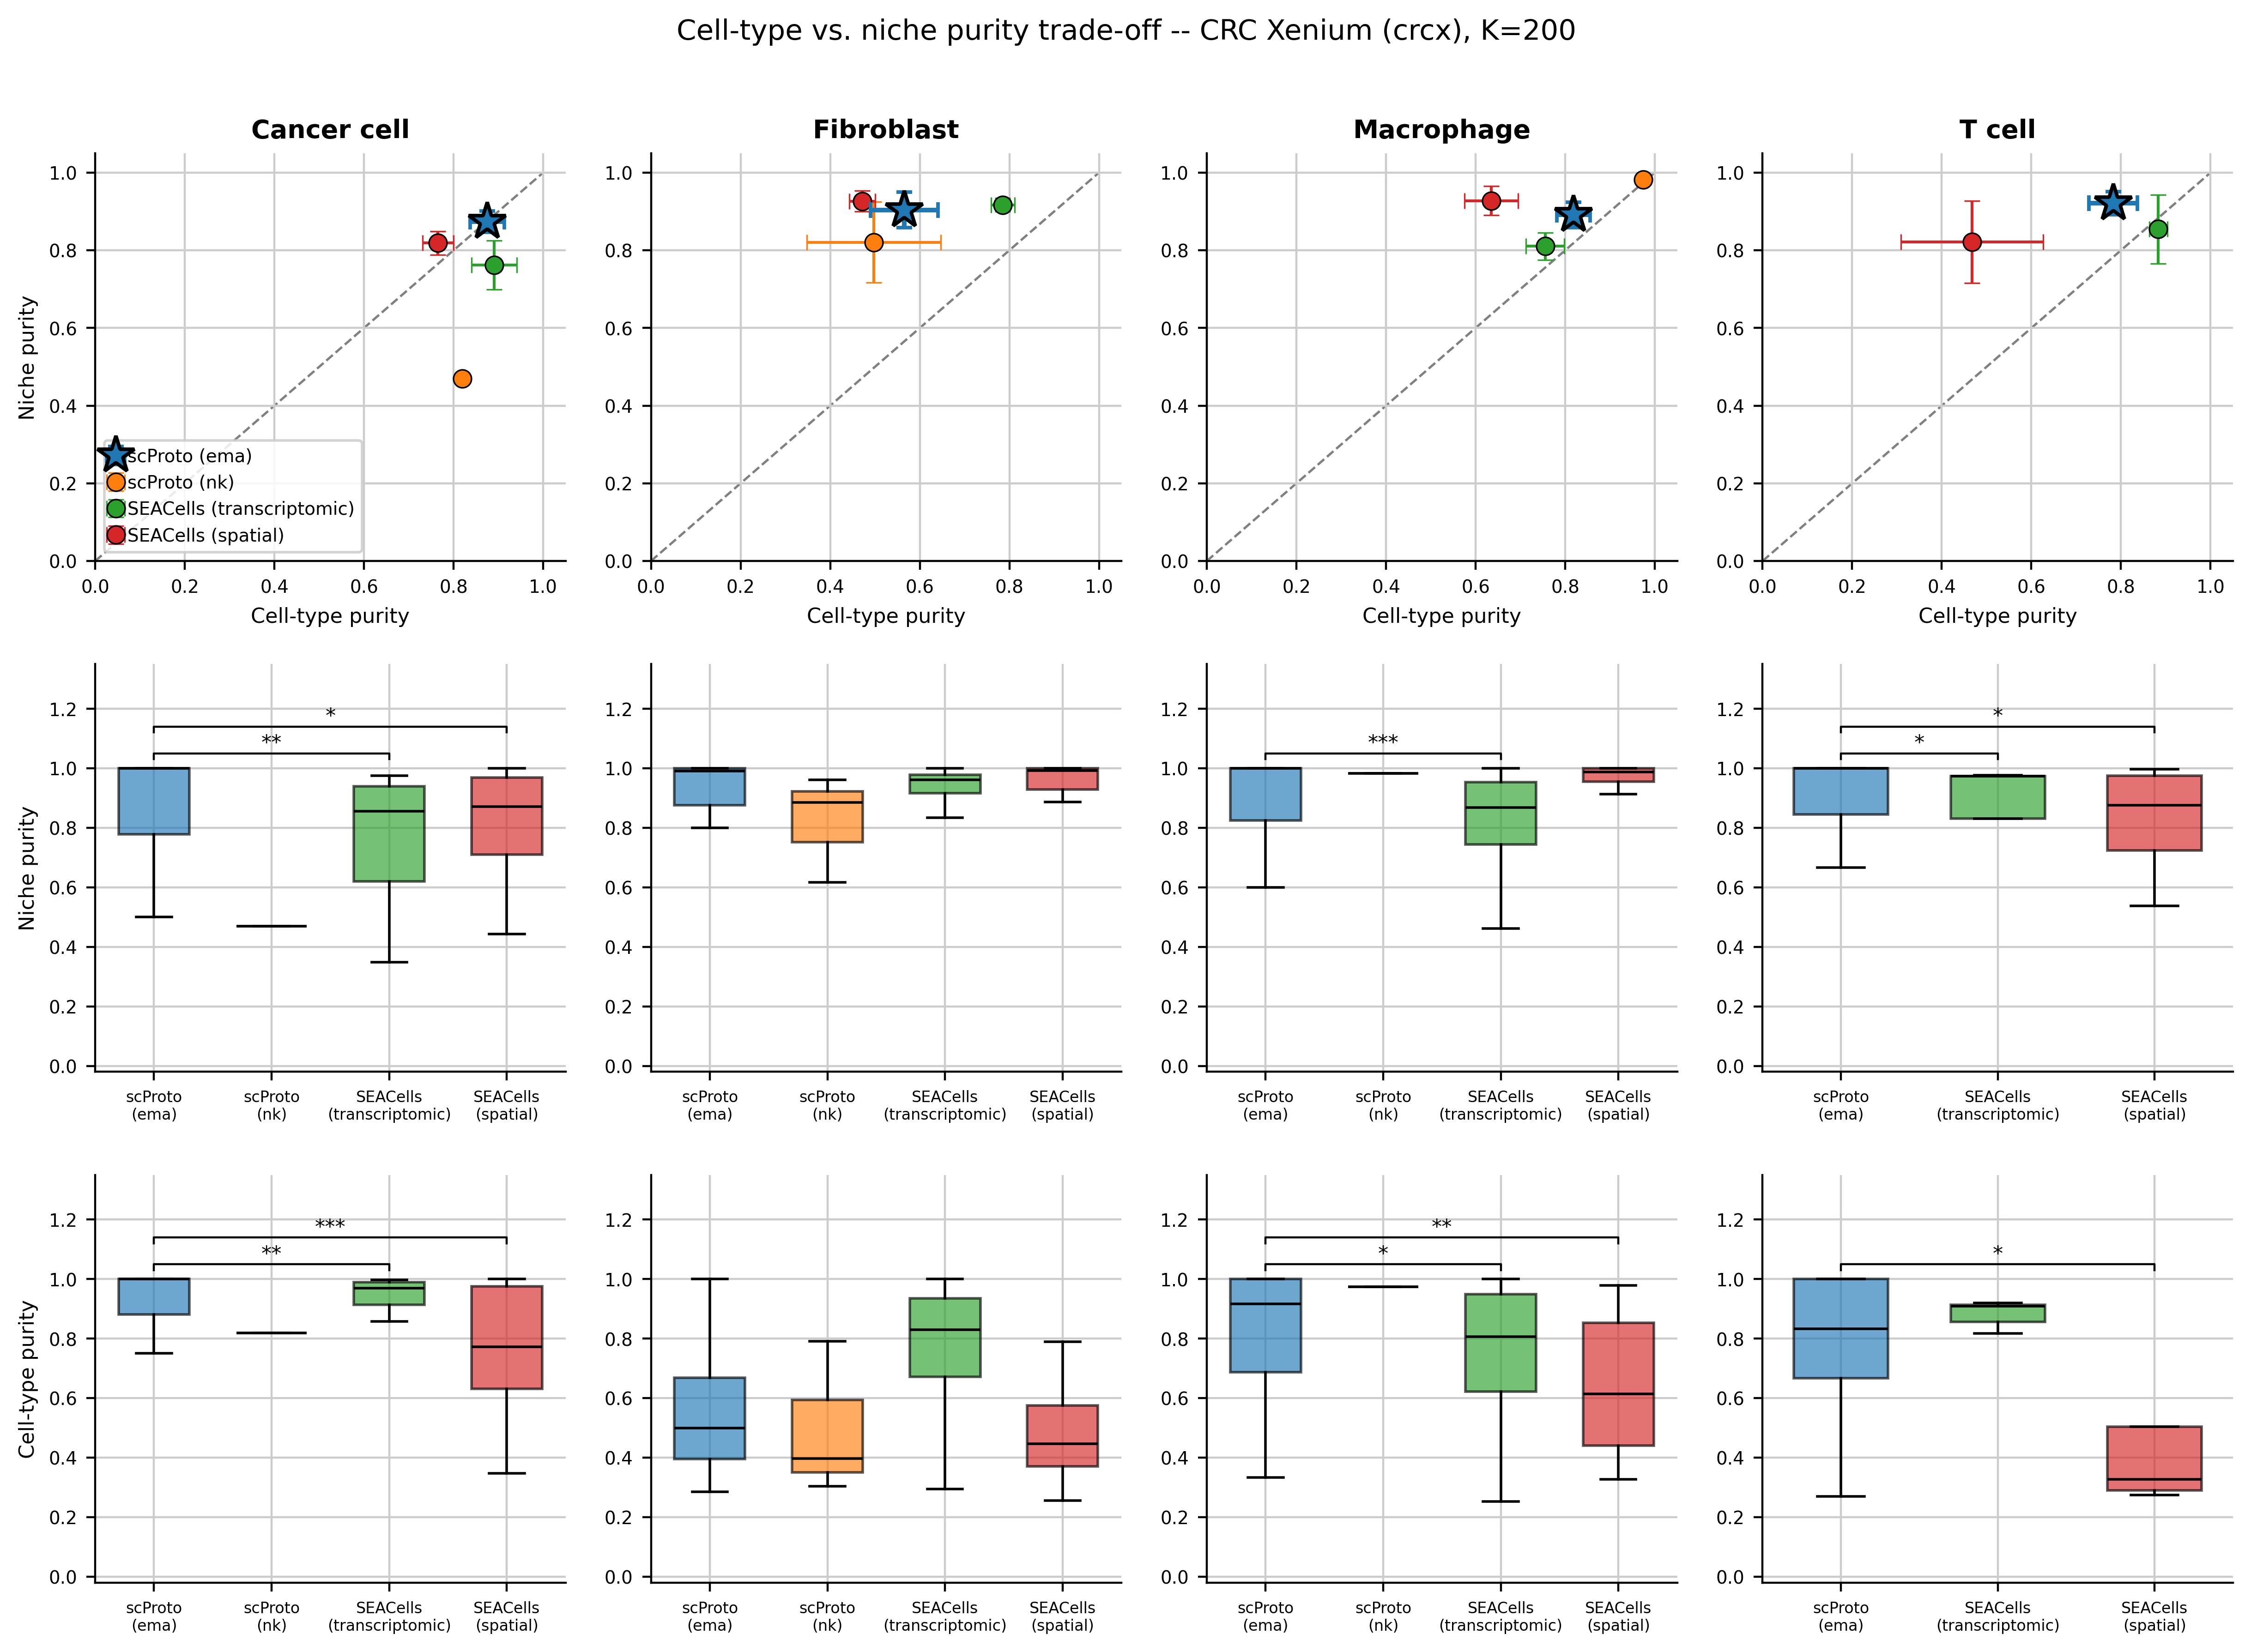

In [21]:
# [fig3-section]
# --- the figure itself: same 3-row layout as the paper's Fig. 3 --------------------
# Row 1: mean +/- SE per method in (ct purity, niche purity) space -- the trade-off.
# Row 2/3: the underlying per-metacell distributions with Mann-Whitney brackets.
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu   # re-imported so this cell runs standalone

# Four cell types spanning the malignant / stromal / immune compartments, the direct
# crcx analogue of Fig. 3's (Tumor, Fibroblasts, Macrophages, Cytotoxic T cells).
FIG3_CELL_TYPES = ['Cancer cell', 'Fibroblast', 'Macrophage', 'T cell']
FIG3_PATH = os.path.join(CODE_DIR, 'files', 'crcx_tradeoff.png')


def _stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else None


def plot_crcx_tradeoff(mc_purity_by_run, cell_types=FIG3_CELL_TYPES, ref_run=REF_RUN,
                       min_mc_size=MIN_MC_SIZE, save_path=FIG3_PATH):
    names = list(mc_purity_by_run)
    colors = {n: c for n, c in zip(names, plt.cm.tab10.colors)}
    n_ct = len(cell_types)

    fig, axes = plt.subplots(3, n_ct, figsize=(3.1 * n_ct, 9.0), squeeze=False)

    for col, ct in enumerate(cell_types):
        sub = {n: d[(d['cell_type'] == ct) & (d['n_cells'] >= min_mc_size)]
               for n, d in mc_purity_by_run.items()}

        # --- row 0: trade-off scatter, mean +/- SE ---
        ax = axes[0, col]
        for n in names:
            x = sub[n]['ct_purity'].dropna().to_numpy()
            y = sub[n]['niche_purity'].dropna().to_numpy()
            if len(x) == 0 or len(y) == 0:
                continue
            xe = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0
            ye = y.std(ddof=1) / np.sqrt(len(y)) if len(y) > 1 else 0.0
            hl = (n == ref_run)
            ax.errorbar(x.mean(), y.mean(), xerr=xe, yerr=ye,
                        fmt='*' if hl else 'o', color=colors[n],
                        markersize=15 if hl else 7, markeredgecolor='black',
                        markeredgewidth=1.4 if hl else 0.6,
                        elinewidth=1.8 if hl else 1.1, capsize=3, label=n,
                        zorder=6 if hl else 5)
        ax.plot([0, 1], [0, 1], ls='--', lw=0.9, color='grey', zorder=1)
        ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
        ax.set_title(ct, fontsize=10, fontweight='bold')
        ax.set_xlabel('Cell-type purity', fontsize=8)
        ax.set_ylabel('Niche purity' if col == 0 else '', fontsize=8)
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.legend(fontsize=7, loc='lower left', framealpha=0.85)

        # --- rows 1/2: distributions + brackets ---
        for row, (metric, ylabel) in enumerate(
                [('niche_purity', 'Niche purity'), ('ct_purity', 'Cell-type purity')], start=1):
            ax = axes[row, col]
            arrays = [sub[n][metric].dropna().to_numpy() for n in names]
            valid = [(i, n, a) for i, (n, a) in enumerate(zip(names, arrays)) if len(a) > 0]
            if not valid:
                ax.set_visible(False)
                continue

            bp = ax.boxplot([a for _, _, a in valid],
                            positions=list(range(1, len(valid) + 1)), widths=0.6,
                            patch_artist=True, showfliers=False)
            for patch, (_, n, _) in zip(bp['boxes'], valid):
                patch.set_facecolor(colors[n]); patch.set_alpha(0.65)
            for med in bp['medians']:
                med.set_color('black')

            ax.set_xticks(list(range(1, len(valid) + 1)))
            ax.set_xticklabels([n.replace(' (', '\n(') for _, n, _ in valid],
                               fontsize=6, rotation=0)
            ax.set_ylabel(ylabel if col == 0 else '', fontsize=8)
            ax.tick_params(axis='y', labelsize=7)
            ax.set_ylim(-0.02, 1.35)

            vnames = [n for _, n, _ in valid]
            if ref_run not in vnames:
                continue
            ref_pos = vnames.index(ref_run) + 1
            ref_arr = valid[vnames.index(ref_run)][2]
            level = 0
            for pos, (_, n, arr) in enumerate(valid, start=1):
                if n == ref_run or len(arr) < 2 or len(ref_arr) < 2:
                    continue
                try:
                    _, p = mannwhitneyu(ref_arr, arr, alternative='greater')
                except ValueError:
                    continue
                s = _stars(p)
                if s is None:
                    continue
                y = 1.03 + 0.09 * level
                x1, x2 = min(ref_pos, pos), max(ref_pos, pos)
                ax.plot([x1, x1, x2, x2], [y, y + 0.02, y + 0.02, y], lw=0.8, color='black')
                ax.text((x1 + x2) / 2, y + 0.02, s, ha='center', va='bottom', fontsize=8)
                level += 1

    fig.suptitle(f'Cell-type vs. niche purity trade-off -- CRC Xenium ({DS_ID}), '
                 f'K={N_PROTOTYPES}', fontsize=11, y=0.997)
    fig.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'saved -> {save_path}')
    return fig


_ = plot_crcx_tradeoff(mc_purity_by_run)
plt.show()

### How to read this section

- **Fig. 3's claim on `crcx`** is the pair of inequalities in the row-1 scatter: scProto above SEACells (transcriptomic) on the y-axis (niche purity) *and* to the right of SEACells (spatial) on the x-axis (cell-type purity). Both have to hold for the trade-off result to replicate on a second tissue and platform.
- **Brackets are one-sided** (`alternative='greater'`, scProto as reference), identical to the test behind Fig. 3's brackets, so stars mean scProto is significantly higher -- not merely different.
- **Modularity in the headline table is scored on the canonical `arbf`-on-PCA graph for every method**, including scProto, which trains on `bk08`. That is the graph scProto never sees.
- **The `>=10`-cell sensitivity table is the one to check before quoting any purity number.** scProto's metacells on `crcx` are much smaller than SEACells', and a 1-2 cell metacell is trivially 100% pure; if a purity advantage only exists without the size floor, it isn't a real advantage.


## Summary & caveats

- `bk08`: real `pybanksy` package, `lambda=0.8`, kernel built with the real SEACells package's own `SEACellGraph.rbf()` -- same graph used by scProto (`ema`/`nk`) and by the `SEACells_bk08` baseline, isolating method from graph.
- `arbf`: standard, unmodified SEACells recipe on plain PCA -- no graph engineering, the true baseline.
- `N_PROTOTYPES`/`N_SEACELLS` are set together in the config cell, informed by the (celltype, niche) pair count printed right before it -- not copied from `s28nsc`'s own value (200), which was tuned to that dataset's own graph/pair-count via a separate Leiden analysis this notebook doesn't repeat.
- Branch 1 (Pearson r + Kendall tau, no significance gate) is the primary evidence; Branch 2 (SuperCell-style TPR) is secondary. `n_pairs_tested` matters as much as the score itself -- a high score on very few tested pairs is not reliable evidence on its own.
- `NICHE_KEY='Niche'` is the source paper's own NicheCompass-derived (GNN) label, used here only to define ground-truth (cell type, niche) DE pairs -- NOT the composition-clustering niche our own method uses, and no niche label from this dataset was used to train scProto itself (affinity graphs are built from spatial coordinates + expression only).